In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
file_path = "../data/raw/orders_train.txt"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (2325165, 15)


In [3]:
df.head()

,orderID,orderDate,articleID,colorCode,sizeCode,productGroup,quantity,price,rrp,voucherID,voucherAmount,customerID,deviceID,paymentMethod,returnQuantity
0,a1000001,2014-01-01,i1000382,1972,44,3.0,1,10.00,29.99,0,0.0,c1010575,2,BPRG,0
1,a1000001,2014-01-01,i1000550,3854,44,3.0,1,20.00,39.99,0,0.0,c1010575,2,BPRG,0
2,a1000002,2014-01-01,i1001991,2974,38,8.0,1,35.00,49.99,0,0.0,c1045905,4,BPRG,0
3,a1000002,2014-01-01,i1001999,1992,38,8.0,1,49.99,49.99,0,0.0,c1045905,4,BPRG,1
4,a1000003,2014-01-01,i1001942,1968,42,8.0,1,10.00,35.99,0,0.0,c1089295,2,PAYPALVC,0


In [4]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
orderID
orderDate
articleID
colorCode
sizeCode
productGroup
quantity
price
rrp
voucherID
voucherAmount
customerID
deviceID
paymentMethod
returnQuantity


In [5]:
print("Dataset shape:", df.shape)
print()

df.info()

Dataset shape: (2325165, 15)

<class 'pandas.DataFrame'>
RangeIndex: 2325165 entries, 0 to 2325164
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   orderID         str    
 1   orderDate       str    
 2   articleID       str    
 3   colorCode       int64  
 4   sizeCode        str    
 5   productGroup    float64
 6   quantity        int64  
 7   price           float64
 8   rrp             float64
 9   voucherID       str    
 10  voucherAmount   float64
 11  customerID      str    
 12  deviceID        int64  
 13  paymentMethod   str    
 14  returnQuantity  int64  
dtypes: float64(4), int64(4), str(7)
memory usage: 360.6 MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
orderID,2325165,738698,a1602669,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orderDate,2325165,638,2014-07-29,9957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
articleID,2325165,3823,i1003278,26208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
colorCode,2325165.0,NaN,NaN,NaN,2148.216467,1740.827036,1000.0,1014.0,1493.0,2854.0,8888.0
sizeCode,2325165,29,38,395163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productGroup,2324814.0,NaN,NaN,NaN,5.958604,6.063121,1.0,3.0,3.0,8.0,90.0
quantity,2325165.0,NaN,NaN,NaN,0.995543,0.164028,0.0,1.0,1.0,1.0,24.0
price,2325165.0,NaN,NaN,NaN,35.399105,22.662477,0.0,20.0,29.99,40.0,623.76
rrp,2324814.0,NaN,NaN,NaN,42.985147,24.011038,0.0,29.99,39.99,49.99,799.99
voucherID,2325159,670,0,1868227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)

print("Missing values:")
print(missing)

Missing values:
productGroup      351
rrp               351
voucherID           6
articleID           0
colorCode           0
orderDate           0
orderID             0
quantity            0
sizeCode            0
price               0
voucherAmount       0
customerID          0
deviceID            0
paymentMethod       0
returnQuantity      0
dtype: int64


In [8]:
print(df["returnQuantity"].value_counts(dropna=False))

returnQuantity
1    1204005
0    1117156
2       3749
3        192
4         35
5         28
Name: count, dtype: int64


In [9]:
print(df["returnQuantity"].value_counts(normalize=True, dropna=False) * 100)

returnQuantity
1    51.781486
0    48.046311
2     0.161236
3     0.008257
4     0.001505
5     0.001204
Name: proportion, dtype: float64


In [10]:
df["returned"] = (df["returnQuantity"] > 0).astype(int)

df[["returnQuantity", "returned"]].head(10)

,returnQuantity,returned
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,1


In [11]:
df["returned"].value_counts()

returned
1    1208009
0    1117156
Name: count, dtype: int64

In [12]:
df["returned"].value_counts(normalize=True) * 100

returned
1    51.953689
0    48.046311
Name: proportion, dtype: float64

In [13]:
print(f"Total rows:       {len(df):,}")
print(f"Unique orders:    {df['orderID'].nunique():,}")
print(f"Unique customers: {df['customerID'].nunique():,}")
print(f"Unique products:  {df['articleID'].nunique():,}")

Total rows:       2,325,165
Unique orders:    738,698
Unique customers: 311,369
Unique products:  3,823


In [14]:
df["returned"] = (df["returnQuantity"] > 0).astype(int)

print(df["returned"].value_counts())
print()
print(df["returned"].value_counts(normalize=True) * 100)

returned
1    1208009
0    1117156
Name: count, dtype: int64

returned
1    51.953689
0    48.046311
Name: proportion, dtype: float64


In [15]:
product_group_returns = (
    df.groupby("productGroup")["returned"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

product_group_returns["return_rate"] = product_group_returns["mean"] * 100

product_group_returns.head(10)

,mean,count,return_rate
productGroup,,,
13.0,0.676833,101214,67.683324
7.0,0.623225,41542,62.322469
50.0,0.617765,8207,61.776532
14.0,0.615971,45283,61.597067
9.0,0.596140,73981,59.613955
1.0,0.594868,205395,59.486842
8.0,0.582717,327473,58.271674
2.0,0.580759,204610,58.075852
5.0,0.541957,82977,54.195741


In [16]:
payment_returns = (
    df.groupby("paymentMethod")["returned"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

payment_returns["return_rate"] = payment_returns["mean"] * 100

payment_returns

,mean,count,return_rate
paymentMethod,,,
BPRG,0.555840,1810036,55.584033
KKE,0.451156,106748,45.115599
BPPL,0.408898,4248,40.889831
PAYPALVC,0.385352,169009,38.535226
BPLS,0.372865,11358,37.286494
VORAUS,0.372512,26877,37.251181
CBA,0.371715,179398,37.171540
NN,0.341613,17271,34.161311
KGRG,0.294686,207,29.468599


In [17]:
device_returns = (
    df.groupby("deviceID")["returned"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

device_returns["return_rate"] = device_returns["mean"] * 100

device_returns

,mean,count,return_rate
deviceID,,,
1,0.638298,47,63.829787
4,0.536948,145921,53.694807
5,0.526238,133698,52.623824
2,0.519731,1663266,51.973106
3,0.509687,382233,50.968650


In [18]:
df["discount_pct"] = (
    (df["rrp"] - df["price"]) / df["rrp"]
) * 100

df[["price", "rrp", "discount_pct"]].head(10)

,price,rrp,discount_pct
0,10.00,29.99,66.655552
1,20.00,39.99,49.987497
2,35.00,49.99,29.985997
3,49.99,49.99,0.000000
4,10.00,35.99,72.214504
5,10.00,35.99,72.214504
6,25.00,39.99,37.484371
7,15.00,39.99,62.490623
8,0.00,59.99,100.000000
9,89.99,89.99,0.000000


In [19]:
df["discount_pct"].describe()

count    2.309609e+06
mean     1.585918e+01
std      2.826629e+01
min     -2.300000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      3.331110e+01
max      1.000000e+02
Name: discount_pct, dtype: float64

In [20]:
suspicious_discounts = df[
    (df["discount_pct"] < 0) |
    (df["discount_pct"] > 100)
]

print("Suspicious rows:", len(suspicious_discounts))

suspicious_discounts[
    ["articleID", "price", "rrp", "discount_pct"]
].sort_values("discount_pct").head(20)

Suspicious rows: 22662


,articleID,price,rrp,discount_pct
482855,i1000783,623.76,25.99,-2300.000000
482854,i1000783,389.85,25.99,-1400.000000
482856,i1000783,285.89,25.99,-1000.000000
482852,i1000783,233.91,25.99,-800.000000
488186,i1000370,114.95,15.00,-666.333333
482851,i1000783,181.93,25.99,-600.000000
2295688,i1000397,89.95,17.99,-400.000000
2312249,i1000397,89.95,17.99,-400.000000
1919409,i1002553,99.95,19.99,-400.000000
1919418,i1002548,99.95,19.99,-400.000000


In [21]:
print("Negative discounts:", (df["discount_pct"] < 0).sum())
print("Over 100% discounts:", (df["discount_pct"] > 100).sum())
print("Missing discounts:", df["discount_pct"].isna().sum())

Negative discounts: 22662
Over 100% discounts: 0
Missing discounts: 15556


In [22]:
print("RRP = 0:", (df["rrp"] == 0).sum())
print("RRP missing:", df["rrp"].isna().sum())

df[df["rrp"] == 0][
    ["articleID", "price", "rrp", "returnQuantity"]
].head(10)

RRP = 0: 15205
RRP missing: 351


,articleID,price,rrp,returnQuantity
1699,i1003987,0.0,0.0,0
3104,i1003987,0.0,0.0,0
3924,i1003987,0.0,0.0,1
5437,i1003987,0.0,0.0,0
5848,i1003987,0.0,0.0,0
6289,i1003987,0.0,0.0,1
7174,i1003987,0.0,0.0,0
8402,i1003987,0.0,0.0,0
9771,i1003987,0.0,0.0,0
14019,i1003987,0.0,0.0,0


In [23]:
df["discount_pct_clean"] = df["discount_pct"]

# Negative discounts are not treated as discounts
df.loc[df["discount_pct_clean"] < 0, "discount_pct_clean"] = 0

# Handle undefined/missing discounts
df["discount_pct_clean"] = df["discount_pct_clean"].fillna(0)

In [24]:
df["discount_pct_clean"].describe()

count    2.325165e+06
mean     1.662890e+01
std      2.549784e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.331110e+01
max      1.000000e+02
Name: discount_pct_clean, dtype: float64

In [25]:
df["price_above_rrp"] = (df["price"] > df["rrp"]).astype(int)

In [26]:
print(df["discount_pct_clean"].describe())

print("\nPrice above RRP:")
print(df["price_above_rrp"].value_counts())

print("\nMissing cleaned discounts:")
print(df["discount_pct_clean"].isna().sum())

count    2.325165e+06
mean     1.662890e+01
std      2.549784e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.331110e+01
max      1.000000e+02
Name: discount_pct_clean, dtype: float64

Price above RRP:
price_above_rrp
0    2302503
1      22662
Name: count, dtype: int64

Missing cleaned discounts:
0


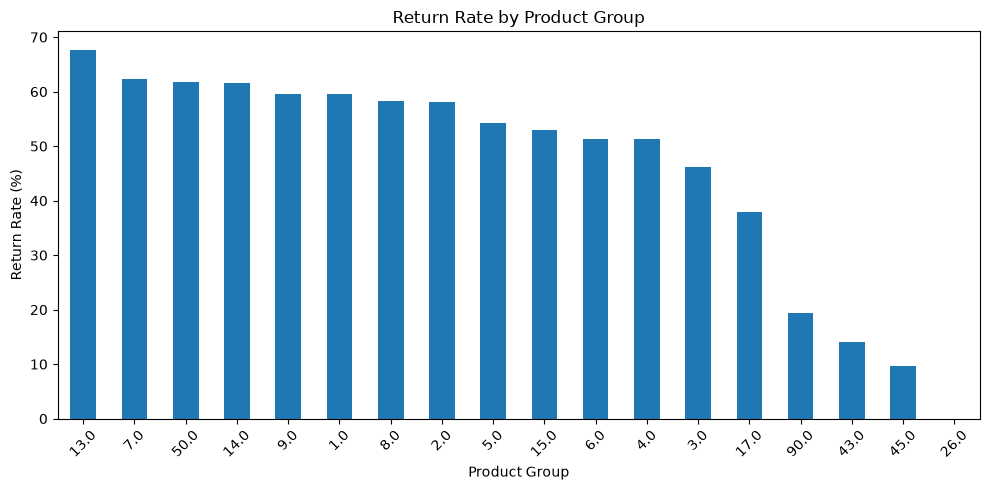

In [27]:
product_group_return = (
    df.groupby("productGroup")["returned"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

product_group_return.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Return Rate by Product Group")
plt.xlabel("Product Group")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

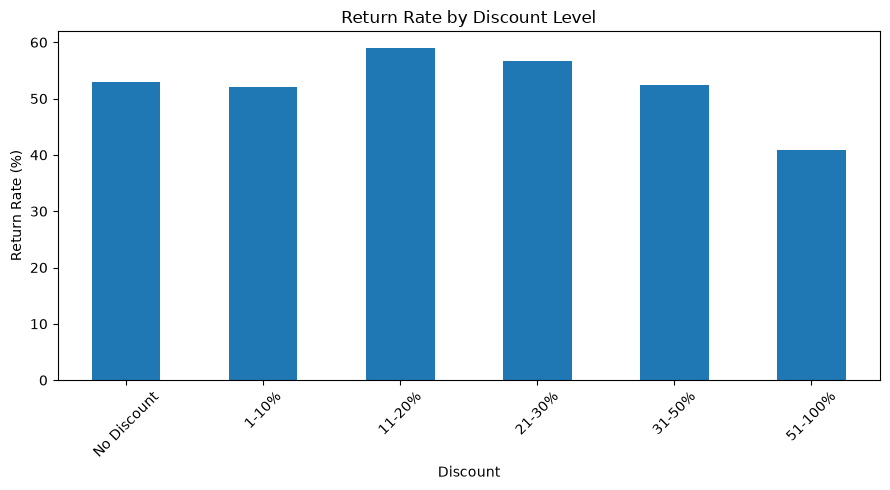

In [28]:
df["discount_bucket"] = pd.cut(
    df["discount_pct_clean"],
    bins=[-1, 0, 10, 20, 30, 50, 100],
    labels=[
        "No Discount",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-50%",
        "51-100%"
    ]
)

discount_return = (
    df.groupby("discount_bucket", observed=False)["returned"]
      .mean()
      * 100
)

discount_return.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Return Rate by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

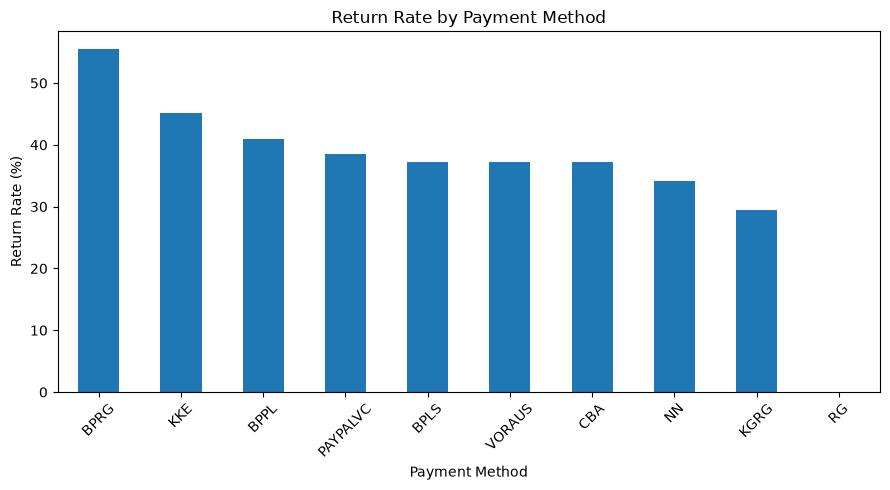

In [29]:
payment_return = (
    df.groupby("paymentMethod")["returned"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

payment_return.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Return Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

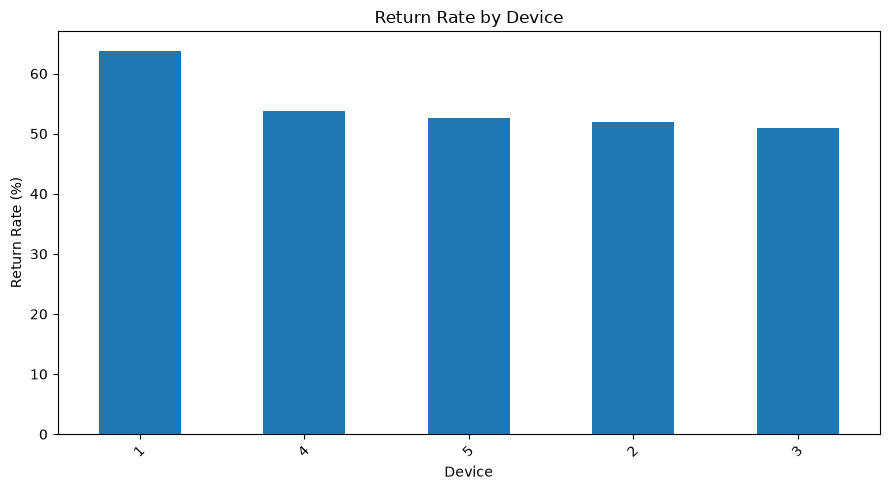

In [30]:
device_return = (
    df.groupby("deviceID")["returned"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

device_return.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Return Rate by Device")
plt.xlabel("Device")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()